# Ejercicio 1: Estadística Descriptiva y Análisis Univariado

Realice un análisis estadístico descriptivo completo de la base de datos.

**Tareas a realizar:**
- Cargue el dataset y examine su estructura básica (dimensiones, tipos de datos, valores faltantes). Para la carga de la base de datos, utilice el comando:
`datos_penguins = sns.load_dataset('penguins')`
Considere los comandos `shape`, `info` y `isnull().sum()` de la librería pandas para explorar la estructura y los valores faltantes.
- Calcule las estadísticas descriptivas fundamentales (media, mediana, moda, desviación estándar, cuartiles) para las variables numéricas. Considere los comandos describe, median y mode de pandas para obtener estos valores de forma directa.
- Calcule estadísticas de orden superior (asimetría y curtosis) e interprete su significado en el contexto del problema. Considere los comandos skew y kurtosis del módulo stats de la librería scipy, aplicados a las series numéricas.
- Genere histogramas para las variables numéricas, evaluando la forma de sus
distribuciones. Considere los comandos hist de pandas y matplotlib, así como
histplot del módulo seaborn.
- Construya boxplots para identificar valores atípicos en las variables numéricas. Considere el comando boxplot de matplotlib o seaborn.
- Identifique la distribución de las variables categóricas mediante tablas de frecuencia. Considere el comando value_counts de pandas para obtener la frecuencia absoluta
de cada categoría.

Genere un reporte descriptivo que caracterice completamente la distribución univariada de cada
variable, identificando patrones, anomalías y características relevantes para análisis posteriores.

# 1.1 Estructura basica del dataset.

In [1]:
import pandas as pd
import seaborn as sns

def eda_resumen(df: pd.DataFrame, top_n=5):
  """Genera un resumen exploratorio (EDA) de un DataFrame.

  Calcula para cada columna data type, cantidad y porcentaje de
  valores nulos, y cantidad de valores unicos. Ademas devuelve
  estadisticos descriptivos generales.

  Args:
    df: DataFrame a analizar.
    top_n: Cantidad de filas a mostrar en la vista previa (head).
  """
  print(f"Dimensiones (filas, columnas): {df.shape}")
  info = pd.DataFrame({
      "dtype": df.dtypes,
      "n_nulos": df.isna().sum(),
      "porcentaje_nulos": df.isna().mean().round(3),
      "n_unicos": df.nunique(),
      "moda":  df.mode().iloc[0]
  })

  return info.sort_index(), df.head(top_n), df.describe(include="all").T

pinguinos = sns.load_dataset("penguins")
info, cabeza, descriptivos = eda_resumen(pinguinos)
print(info)

Dimensiones (filas, columnas): (344, 7)
                     dtype  n_nulos  porcentaje_nulos  n_unicos    moda
bill_depth_mm      float64        2             0.006        80    17.0
bill_length_mm     float64        2             0.006       164    41.1
body_mass_g        float64        2             0.006        94  3800.0
flipper_length_mm  float64        2             0.006        55   190.0
island                 str        0             0.000         3  Biscoe
sex                    str       11             0.032         2    Male
species                str        0             0.000         3  Adelie


El dataset tiene 344 observaciones y 7 columnas (3 categóricas:
`species`, `island`, `sex`; 4 numéricas: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`). Hay valores faltantes acotados: 2 filas con las cuatro medidas numéricas ausentes simultáneamente (probablemente el mismo registro incompleto) y 11 filas sin dato de `sex`. Al ser pocos casos sobre el total, se pueden excluir con `dropna()` para los análisis que lo requieran sin perder representatividad.


In [2]:
cabeza

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


# 1.2 Estadisticas descriptivas

In [3]:
# estadisticas descriptivas para las numericas
# .describe() ya trabaja por default con columnas numericas
# pinguinos.describe()
import numpy as np

numericas = pinguinos.select_dtypes(include=[np.number])
resumen = numericas.agg(["count", "mean", "median", "std", "min", "max"]).T
resumen["IQR"] = numericas.quantile(0.75) - numericas.quantile(0.25)
print(resumen.round(2))

                   count     mean   median     std     min     max      IQR
bill_length_mm     342.0    43.92    44.45    5.46    32.1    59.6     9.27
bill_depth_mm      342.0    17.15    17.30    1.97    13.1    21.5     3.10
flipper_length_mm  342.0   200.92   197.00   14.06   172.0   231.0    23.00
body_mass_g        342.0  4201.75  4050.00  801.95  2700.0  6300.0  1200.00


In [4]:
numericas.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Las cuatro variables numéricas tienen escalas muy distintas (`bill_depth_mm` ronda los 17 mm mientras `body_mass_g` ronda los 4200 g), por lo que cualquier comparación directa de dispersión entre ellas requiere normalizar. La media y la mediana están cercanas entre sí en las cuatro variables, lo que sugiere ausencia de asimetría extrema.


# 1.3 Estadisticos de orden superior: asimetria y curtosis

In [5]:
from scipy import stats

# asimetria = {}
# curtosis = {}

# for col in numericas.columns:
#     datos = numericas[col].dropna()
#     asimetria[col] = stats.skew(datos)
#     curtosis[col] = stats.kurtosis(datos)


asimetria = numericas.apply(lambda col: stats.skew(col.dropna()))
curtosis = numericas.apply(lambda col: stats.kurtosis(col.dropna()))

resultados = pd.DataFrame({"asimetria": asimetria, "curtosis": curtosis})
print(resultados)

                   asimetria  curtosis
bill_length_mm      0.052885 -0.880765
bill_depth_mm      -0.142835 -0.911155
flipper_length_mm   0.344164 -0.987434
body_mass_g         0.468264 -0.726243


Explicacion: ** llenar **

# 1.4 Histogramas

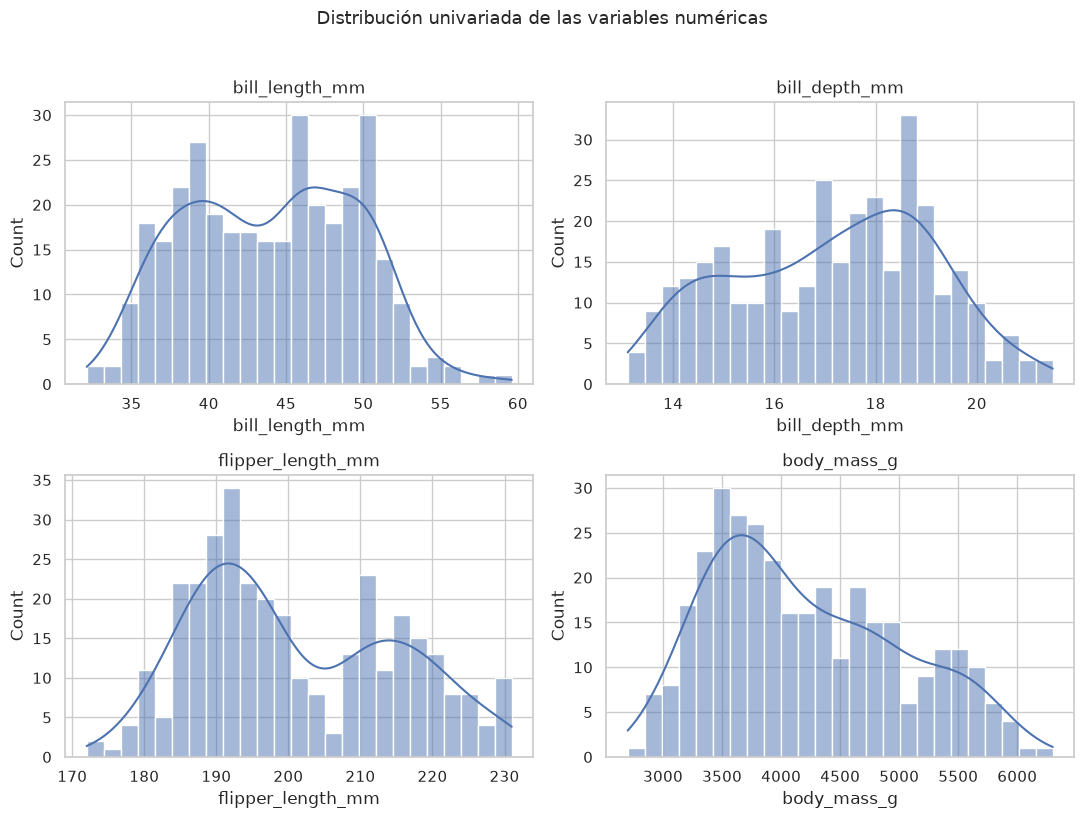

In [6]:
# Nota de maxip: aca hay que tener cuidado, porque las visualizaciones ellos toman
# de que sean lindos tambien los graficos pero hay que estar piyos para explicar.

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

pinguinos = sns.load_dataset("penguins").dropna()
numericas = pinguinos.select_dtypes(include="number")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), numericas):
    sns.histplot(pinguinos[col], bins=25, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
fig.suptitle("Distribución univariada de las variables numéricas", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


`bill_length_mm` y `body_mass_g` muestran una forma bimodal / multimodal, señal de que mezclan especies con tamaños distintos. `bill_depth_mm` y `flipper_length_mm` también insinúan dos grupos. Esto anticipa que la variable `species` va a ser un fuerte factor explicativo de estas distribuciones.

# 1.5 - Boxplots

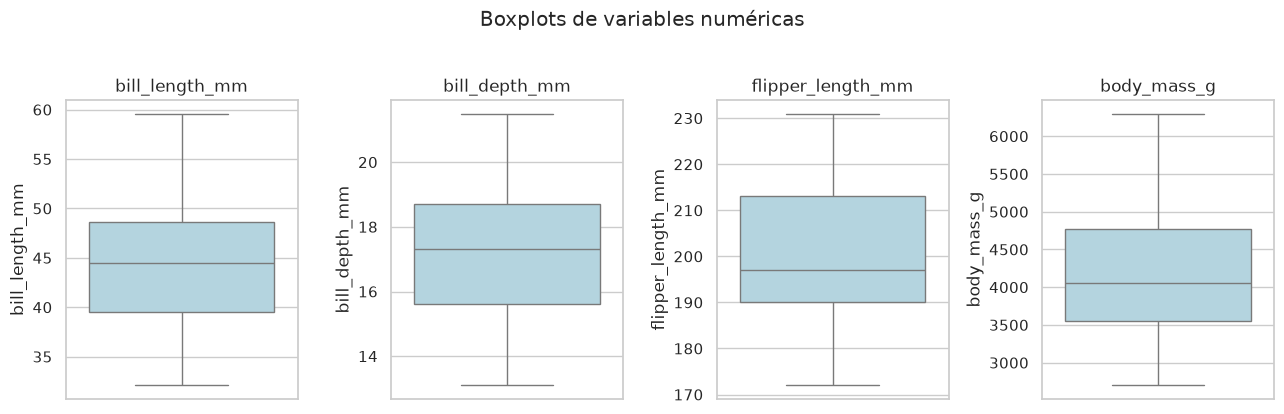

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

pinguinos = sns.load_dataset("penguins").dropna()
numericas = pinguinos.select_dtypes(include="number")

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, col in zip(axes, numericas):
    sns.boxplot(y=pinguinos[col], ax=ax, color="#add8e6")
    ax.set_title(col)
fig.suptitle("Boxplots de variables numéricas", y=1.03)
fig.tight_layout()
plt.show()


Ninguna variable numérica presenta una cantidad relevante de outliers según el
criterio del IQR, el cual es un resultado esperable dada la curtosis negativa/cercana a 0 observada antes. El dataset no muestra errores de carga evidentes ni valores extremos que requieran tratamiento especial.

In [8]:
categoricas = pinguinos.select_dtypes(include="object")

for col in categoricas.columns:
    print(f"Frecuencia de {col}:")
    tabla = pd.DataFrame({
        "n": pinguinos[col].value_counts(),
        "%": (pinguinos[col].value_counts(normalize=True) * 100).round(1)
    })
    print(tabla)
    print()

Frecuencia de species:
             n     %
species             
Adelie     146  43.8
Gentoo     119  35.7
Chinstrap   68  20.4

Frecuencia de island:
             n     %
island              
Biscoe     163  48.9
Dream      123  36.9
Torgersen   47  14.1

Frecuencia de sex:
          n     %
sex              
Male    168  50.5
Female  165  49.5



/tmp/ipykernel_163526/1965475303.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = pinguinos.select_dtypes(include="object")


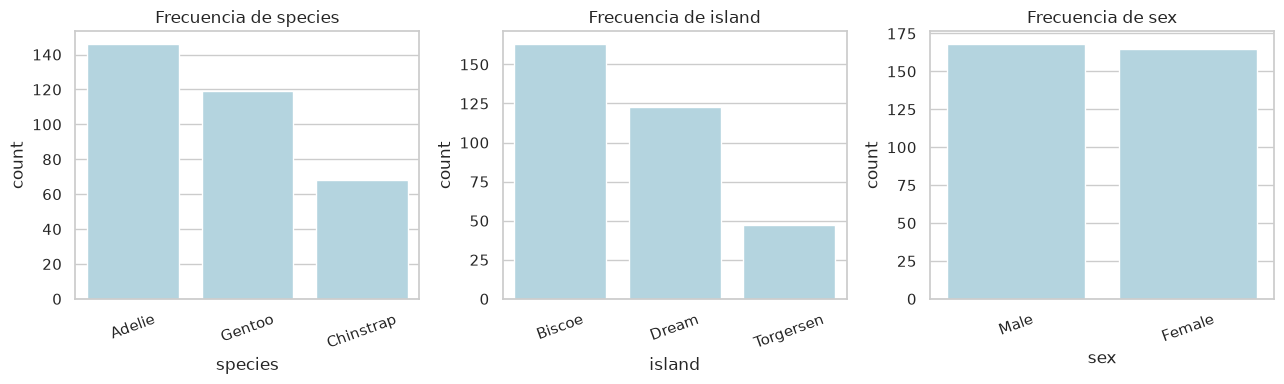

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, categoricas):
    orden = pinguinos[col].value_counts().index
    sns.countplot(x=pinguinos[col], order=orden, ax=ax, color="#add8e6")
    ax.set_title(f"Frecuencia de {col}")
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

`species` está moderadamente desbalanceada (Adelie es la más numerosa, Chinstrap la menos), lo mismo que `island` (Biscoe concentra la mayoría de los registros, en gran parte por ser la única isla donde habita Gentoo). `sex` está prácticamente balanceada entre machos y hembras, salvo los 11 valores faltantes ya señalados.


# Ejercicio 2: Análisis Bivariado - Correlaciones y Asociaciones 
Explore las relaciones entre pares de variables utilizando técnicas de análisis bivariado. Tareas a realizar: 
- Calcule la matriz de correlación para todas las variables numéricas y visualícela mediante un heatmap. Considere el comando `corr` de pandas para calcular la matriz. Para la visualización, utilice `heatmap` de seaborn o `DataFrame.plot.imshow` de pandas. 
- Genere scatter plots para las relaciones más significativas, incorporando líneas de tendencia. Considere el comando `scatterplot` de seaborn o `matplotlib.pyplot.scatter` para graficar puntos. Para incluir líneas de tendencia, utilice lmplot de seaborn. 
- Identifique correlaciones espurias y evalúe la significancia estadística de las asociaciones encontradas. Considere el comando `corr` de pandas o `corrcoef` de 
numpy para calcular coeficientes, y utilice las funciones pearsonr o spearmanr del módulo stats de scipy para obtener el valor del coeficiente y su significancia (valor p). 
- Analice la relación entre "bill_length_mm" y "bill_depth_mm" segmentada por especie utilizando gráficos de dispersión con codificación por color. Considere el comando scatterplot de seaborn. Si se desea añadir una línea de tendencia, puede emplear `lmplot` de seaborn.
- Construya tablas de contingencia para examinar la asociación entre variables categóricas. Considere el comando crosstab de pandas para generar tablas de doble 
entrada entre variables categóricas. 
- Aplique pruebas de independencia chi-cuadrado para variables categóricas. Considere el comando chi2_contingency del módulo stats de scipy, aplicado a las tablas 
generadas con crosstab de pandas o contingency.crosstab de scipy.stats. 

Genere un reporte que incluya una caracterización completa de las relaciones bivariadas que 
permita identificar variables predictoras potenciales y patrones de dependencia entre 
características de las propiedades.  

### 2.1 Matriz de correlación y heatmap

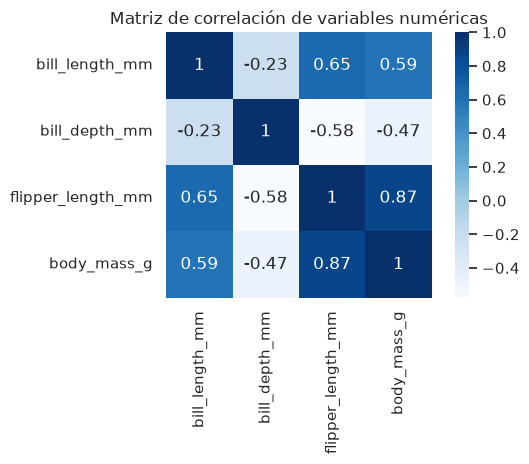

In [50]:
matriz_corr = pinguinos.select_dtypes(include="number").corr()

sns.heatmap(matriz_corr, annot=True, cmap="Blues", square=True)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()


**Lectura:** `flipper_length_mm` y `body_mass_g` están fuertemente correlacionadas(r cercano a uno):
pingüinos con aletas más largas tienden a pesar más, lo cual es biológicamente esperable (aves de
mayor porte). `bill_depth_mm` correlaciona negativamente con las demás variables.

Es importante recordar que correlacion no implica causalidad; esta correlación negativa podría ser espuria, producto de mezclar especies con formas
de pico distintas (paradoja de Simpson), por lo que se revisará luego

**Paradoja de Simpson**: Es un fenómeno estadístico donde una tendencia que aparece en varios grupos de datos por separado se invierte o desaparece cuando juntás esos grupos en uno solo.


### 2.2 Scatter plots con línea de tendencia para las relaciones más significativas

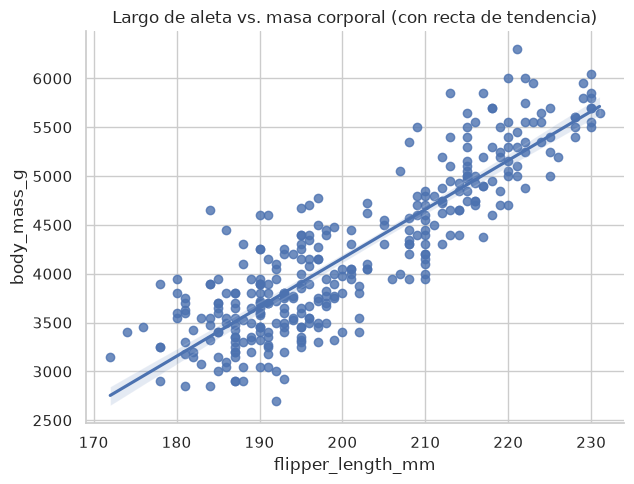

In [11]:
sns.lmplot(data=pinguinos,
           x="flipper_length_mm", y="body_mass_g",
           height=5, aspect=1.3) # width = height * aspect
plt.title("Largo de aleta vs. masa corporal (con recta de tendencia)")
plt.tight_layout()
plt.show()

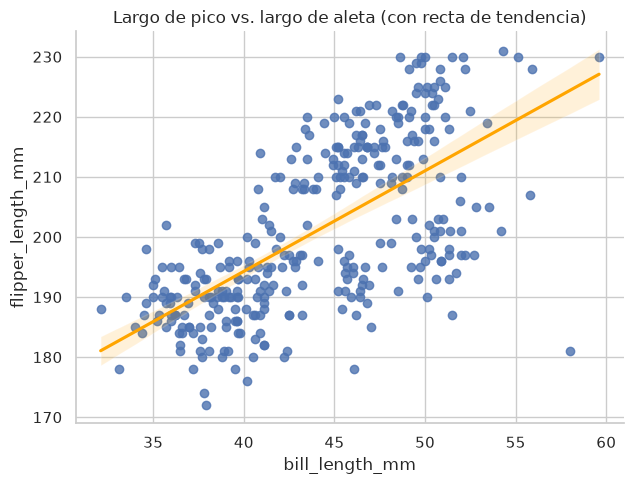

In [12]:
sns.lmplot(data=pinguinos, 
           x="bill_length_mm", y="flipper_length_mm",
           height=5, aspect=1.3, line_kws={"color": "orange"})
plt.title("Largo de pico vs. largo de aleta (con recta de tendencia)")
plt.tight_layout()
plt.show()

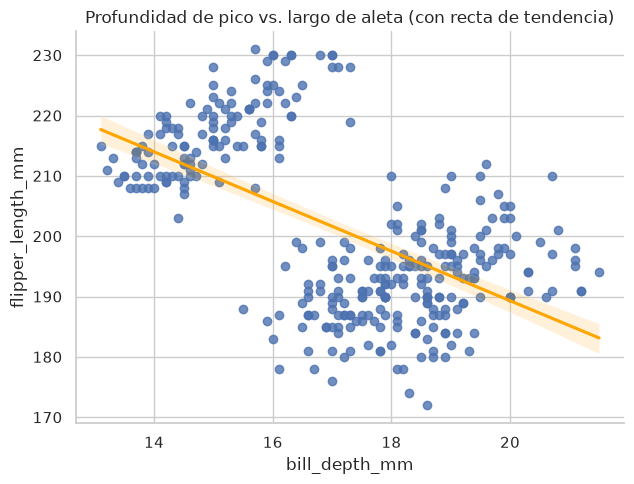

In [109]:
sns.lmplot(data=pinguinos, 
           x="bill_depth_mm", y="flipper_length_mm",
           height=5, aspect=1.3, line_kws={"color": "orange"})
plt.title("Profundidad de pico vs. largo de aleta (con recta de tendencia)")
plt.tight_layout()
plt.show()

### 2.3 Significancia estadística de las asociaciones

In [14]:
# TODO: hacer las otras (MaxiZ)
from scipy.stats import pearsonr, spearmanr

# significancia -> alpha = 0.05
# H0) No existe correlacion lineal entre las dos variables
# H1) noH0)

r, p_valor = pearsonr(pinguinos["flipper_length_mm"], pinguinos["body_mass_g"])
r_spearman, p_valor_spearman = spearmanr(pinguinos["flipper_length_mm"], pinguinos["body_mass_g"])
print(f"r = {r:.3f}, p = {p_valor}")
print(f"r = {r_spearman:.3f}, p = {p_valor_spearman}")

r = 0.873, p = 3.1328362509712445e-105
r = 0.840, p = 4.630423990534309e-90


Pearson mide qué tan bien se ajustan los datos a una relación lineal específica.

Spearman primero convierte cada variable en rangos y después calcula la correlación de Pearson sobre esos rangos. Solo le importa si la correlacion es monótona (que cuando una variable sube, la otra consistentemente sube o consistentemente baja, sin importar a qué ritmo).

**Conclusiones**:
- Tamanio de la aleta vs Peso corporal: como p_valor < alpha, rechazamos H0) y concluimos que hay evidencia significativa para decir que estan correlacionadas.

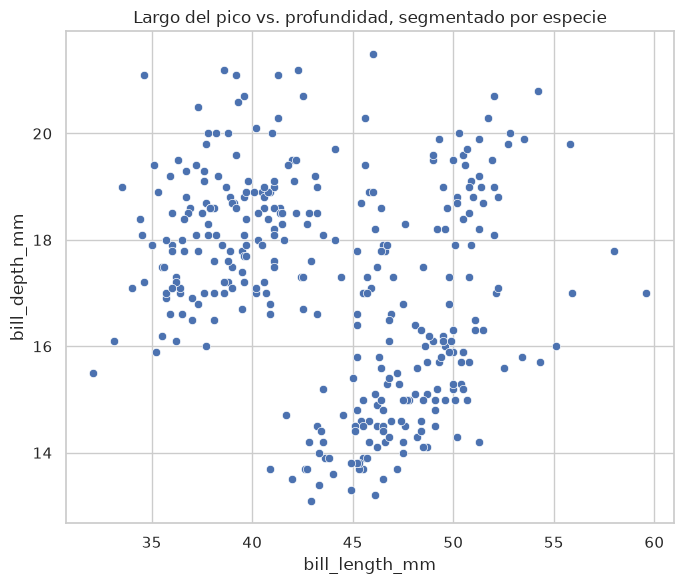

In [15]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=pinguinos, x="bill_length_mm", y="bill_depth_mm")
plt.title("Largo del pico vs. profundidad, segmentado por especie")
plt.tight_layout()
plt.show()

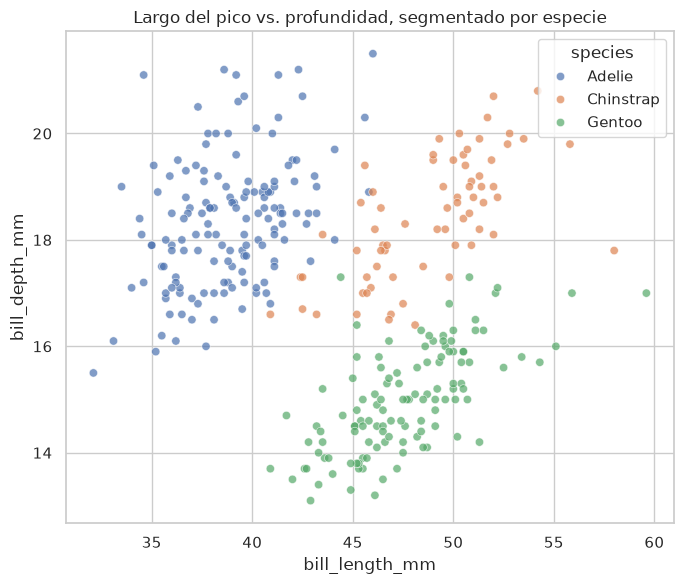

In [16]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=pinguinos, x="bill_length_mm", y="bill_depth_mm", 
                hue="species", alpha=0.7)
plt.title("Largo del pico vs. profundidad, segmentado por especie")
plt.tight_layout()
plt.show()

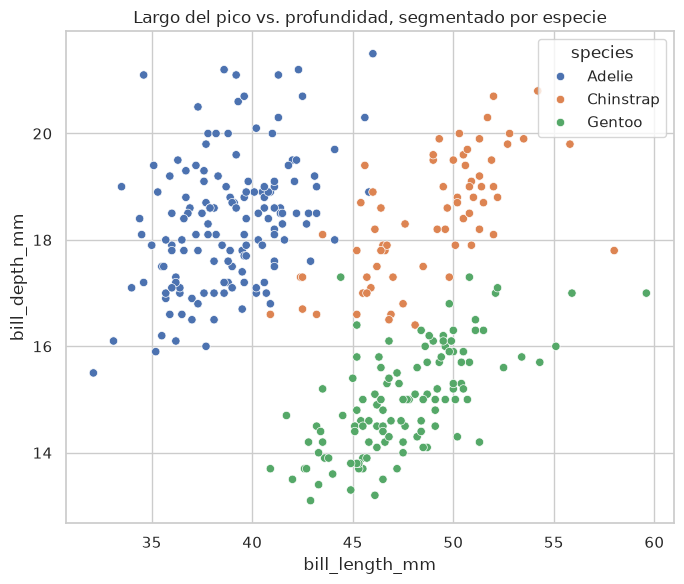

In [17]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=pinguinos, x="bill_length_mm", y="bill_depth_mm", 
                hue="species")
plt.title("Largo del pico vs. profundidad, segmentado por especie")
plt.tight_layout()
plt.show()

In [18]:
r_global = pinguinos["bill_length_mm"].corr(pinguinos["bill_depth_mm"])
print(f"Correlacion global (sin segmentar): {r_global:.3f}\n")

for esp, sub in pinguinos.groupby("species", observed=True):
    r = sub["bill_length_mm"].corr(sub["bill_depth_mm"])
    print(f"Correlación dentro de {esp}: {r:.3f}")

Correlacion global (sin segmentar): -0.229

Correlación dentro de Adelie: 0.386
Correlación dentro de Chinstrap: 0.654
Correlación dentro de Gentoo: 0.654


**Es la paradoja de Simpson en acción:** sin distinguir especie, `bill_length_mm` y `bill_depth_mm`
muestran correlación global negativa. Pero al segmentar por especie, la correlación
**dentro** de cada especie es positiva. Esto confirma que la correlación negativa global es
**espuria**: no refleja una relación biológica real entre largo y profundidad del pico, sino un
artefacto de que las tres especies ocupan regiones distintas del plano. `species` es la variable de
confusión (*confounder*) que explica el cambio de signo.

### 2.5 Tablas de contingencia entre variables categóricas

In [19]:
tabla_especie_isla = pd.crosstab(pinguinos["species"], pinguinos["island"])
tabla_especie_isla

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,55,47
Chinstrap,0,68,0
Gentoo,119,0,0


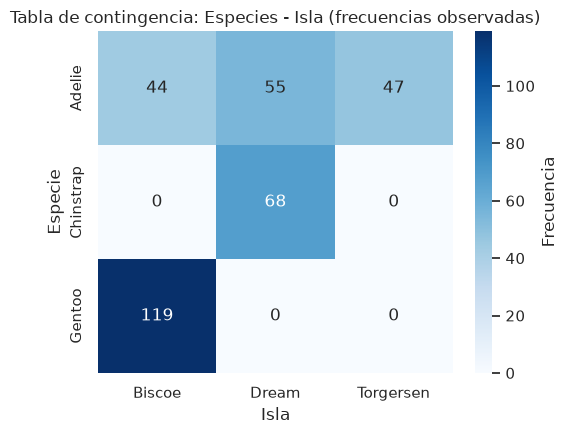

In [20]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(tabla_especie_isla, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Frecuencia"})
plt.title("Tabla de contingencia: Especies - Isla (frecuencias observadas)")
plt.ylabel("Especie")
plt.xlabel("Isla")
plt.tight_layout()
plt.show()

In [21]:
tabla_especie_sexo = pd.crosstab(pinguinos["species"], pinguinos["sex"])
tabla_especie_sexo

sex,Female,Male
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


**Lectura:** el heatmap de `species x island` muestra un patrón diagonal-disperso muy marcado —
Chinstrap y Gentoo aparecen concentrados en una única isla cada una (Dream y Biscoe
respectivamente), mientras Adelie es la única especie presente en las tres. 
TODO: Revisar

In [22]:
chi2b, pb, glb, esperadob = stats.chi2_contingency(tabla_especie_sexo)
print(f"species x sex -> chi2 = {chi2b:.2f}, gl = {glb}, p-valor = {pb:.3f}")
print("Interpretacion: p > 0.05 -> no hay evidencia de asociacion entre especie y sexo")
print("(el sexo esta aproximadamente balanceado dentro de cada especie).")

species x sex -> chi2 = 0.05, gl = 2, p-valor = 0.976
Interpretacion: p > 0.05 -> no hay evidencia de asociacion entre especie y sexo
(el sexo esta aproximadamente balanceado dentro de cada especie).


## Ejercicio 3: Análisis Multivariado y Visualización Avanzada

Implemente técnicas de análisis multivariado para explorar relaciones complejas entre múltiples variables simultáneamente.

**Tareas a realizar:**

- Construya una matriz de dispersión (scatter plot matrix) para visualizar todas las relaciones por pares entre variables numéricas. Considere `pairplot` de seaborn o `scatter_matrix` de pandas.plotting.
- Implemente un gráfico de coordenadas paralelas para identificar patrones en las variables morfológicas de las diferentes especies. Considere `parallel_coordinates` de pandas.plotting o `matplotlib.pyplot.plot` con datos normalizados.
- Genere heatmaps de correlación segmentados por especie de pingüino. Considere `corr` de pandas junto con `heatmap` de seaborn, filtrando por especie.
- Aplique técnicas de agrupamiento de variables basadas en correlación para identificar grupos de características morfológicas relacionadas. Considere `corr` de pandas junto con `linkage` y `dendrogram` de scipy.cluster.hierarchy.
- Construya gráficos de radar (spider plots) para comparar variables morfológicas promedio entre especies. Considere `matplotlib.pyplot.plot` en coordenadas polares (`subplot(projection='polar')`).

Genere un reporte analizando la estructura multivariada de los datos, e identifique patrones morfológicos asociados con la especie que permita identificar características discriminantes.

### 3.1 Matriz de dispersión (pairplot) coloreada por especie

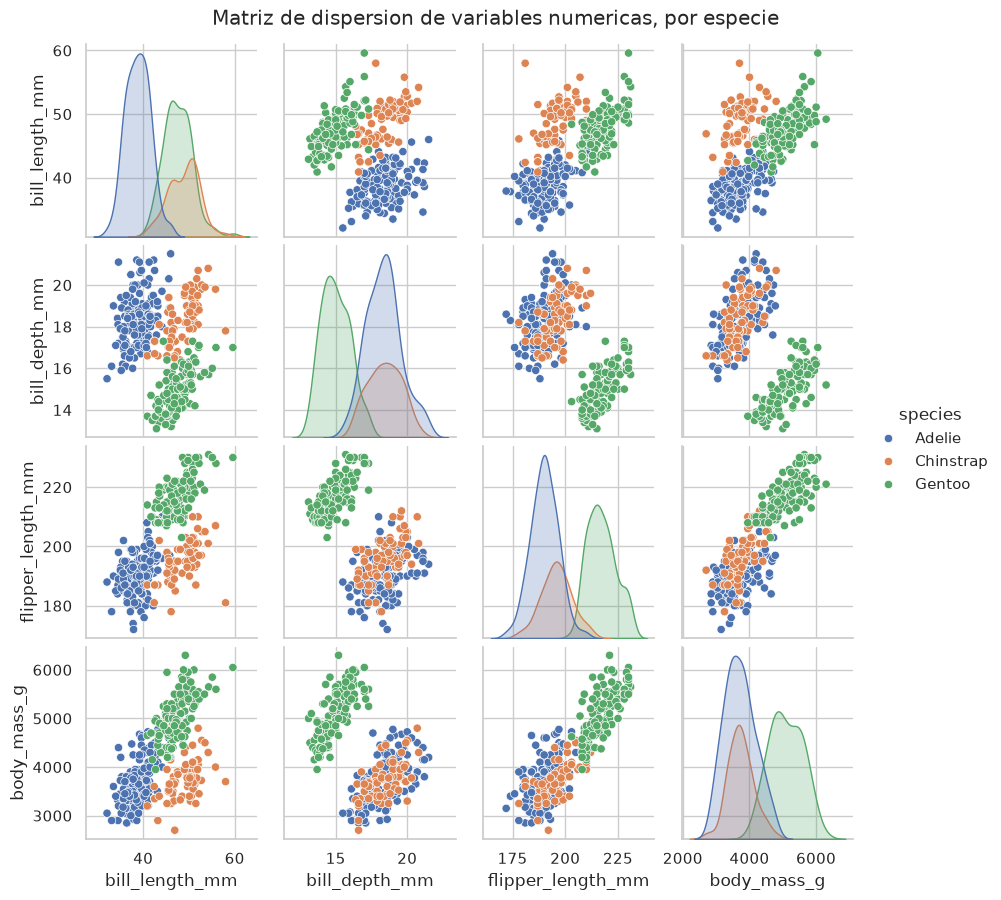

In [ ]:
sns.pairplot(pinguinos, vars=numericas, hue="species", diag_kind="kde", height=2.2)
plt.suptitle("Matriz de dispersion de variables numericas, por especie", y=1.02)
plt.show()

Las variables morfológicas relacionadas con el tamaño (aleta y masa corporal) diferencian principalmente a Gentoo del resto, mientras que la profundidad y longitud del pico son claves para distinguir entre Adelie y Chinstrap.

### 3.2 Coordenadas paralelas

In [ ]:
from sklearn.preprocessing import MinMaxScaler

num_cols = numericas.columns

scaler = MinMaxScaler()
normalizado = pd.DataFrame(
    scaler.fit_transform(pinguinos[num_cols]),
    columns=num_cols
)
normalizado["species"] = pinguinos["species"].to_numpy()

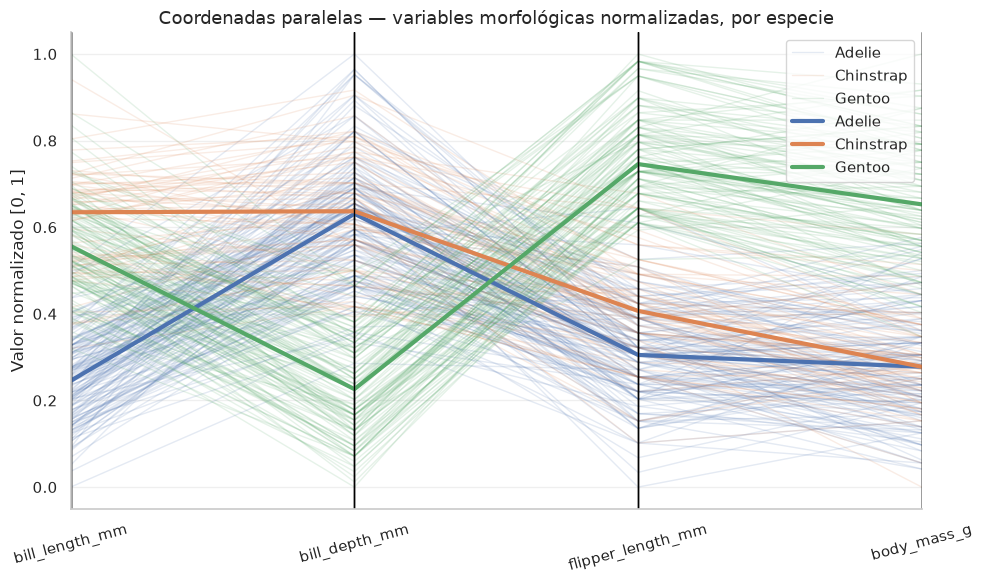

In [41]:
from pandas.plotting import parallel_coordinates

paleta = sns.color_palette("deep", 3)

fig, ax = plt.subplots(figsize=(10, 6))

# Líneas individuales, bien tenues, para mostrar la dispersión
parallel_coordinates(normalizado, "species", color=paleta, alpha=0.15, linewidth=1, ax=ax)

# Líneas de la mediana por especie, marcadas, para que el patrón se vea claro
medianas = normalizado.groupby("species")[num_cols].median()
medianas["species"] = medianas.index
parallel_coordinates(medianas, "species", color=paleta, alpha=1, linewidth=3, ax=ax)

# Limpieza de leyenda: sacamos duplicados (individuales + medianas)
# handles, labels = ax.get_legend_handles_labels()
# n_especies = normalizado["species"].nunique()
# ax.legend(handles[:n_especies], labels[:n_especies], title="species", loc="upper right")

ax.set_title("Coordenadas paralelas — variables morfológicas normalizadas, por especie", fontsize=13)
ax.set_ylabel("Valor normalizado [0, 1]")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.grid(axis="y", alpha=0.3)
sns.despine()

fig.tight_layout()
plt.show()

Gentoo se distingue claramente por tener flipper_length_mm y body_mass_g mucho más altos que las otras dos especies, mientras que Adelie y Chinstrap son parecidas en tamaño corporal pero se diferencian sobre todo en bill_length_mm (Chinstrap más alto).

### 3.3 Heatmaps de correlación segmentados por especie

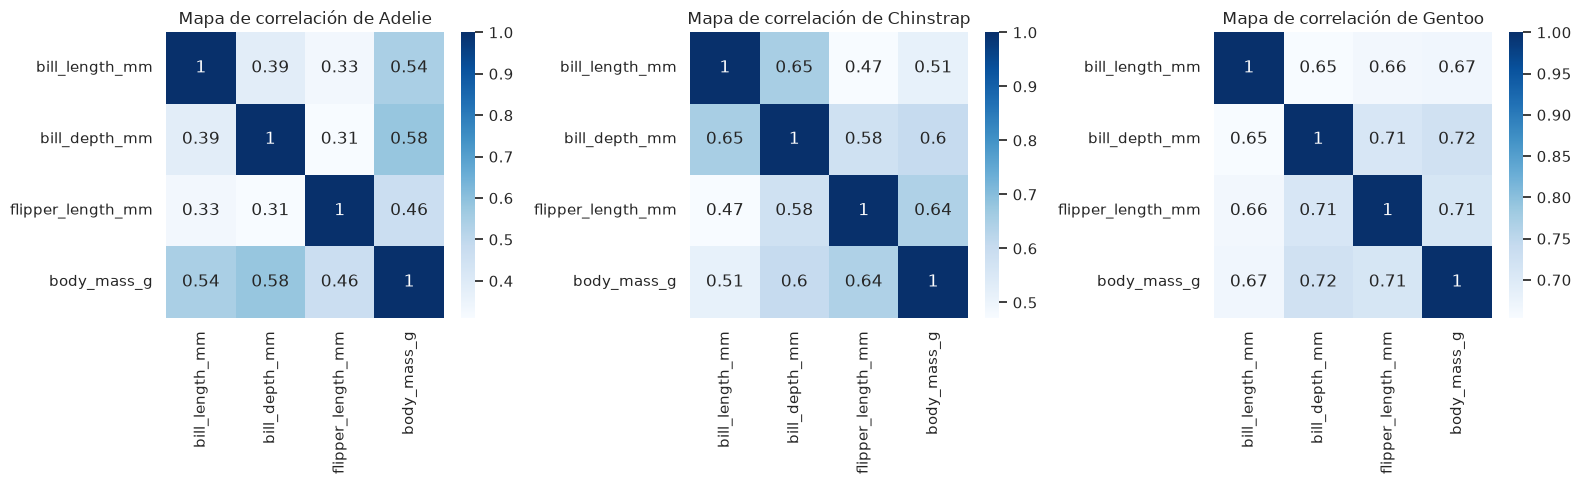

In [49]:
especies = pinguinos["species"].unique()

fig, axes = plt.subplots(1, len(especies), figsize=(16, 5))

for ax, especie in zip(axes, especies):
    datos_especie = pinguinos[pinguinos["species"] == especie]
    correlacion = datos_especie.select_dtypes("number").corr()
    sns.heatmap(correlacion, annot=True, cmap="Blues", linecolor="white", ax=ax)
    ax.set_title(f"Mapa de correlación de {especie}")

fig.tight_layout()
plt.show()

Al segmentar por especie, `bill_length_mm` y `bill_depth_mm` correlacionan **positivamente** en las tres especies (confirmando la paradoja de Simpson detectada antes). 

### 3.4 Agrupamiento jerárquico de variables por correlación (dendrograma)

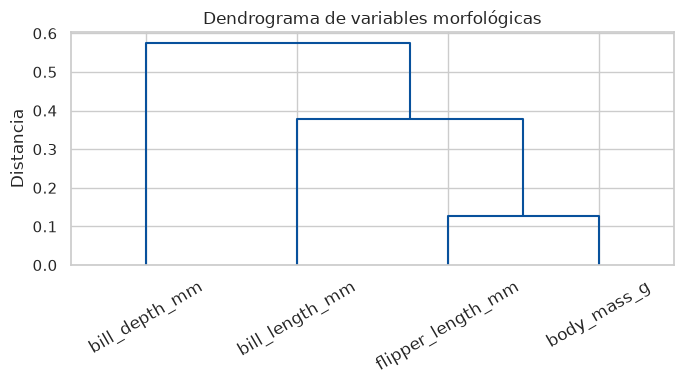

In [61]:
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette
from scipy.spatial.distance import squareform

set_link_color_palette(["#08519c", "#3182bd", "#6baed6", "#9ecae1"])

# Distancia entre variables: 1 - |correlación|
dist = 1 - pinguinos[num_cols].corr().abs()

# squareform convierte la matriz cuadrada de distancias al formato "condensado" que pide linkage
enlace = linkage(squareform(dist), method="average")

plt.figure(figsize=(7, 4))
dendrogram(enlace, labels=num_cols, leaf_rotation=30, above_threshold_color="#08519c")
plt.title("Dendrograma de variables morfológicas")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

flipper_length_mm y body_mass_g son las variables más correlacionadas entre sí (se agrupan primero, a menor distancia), formando un grupo de tamaño corporal al que luego se suma bill_length_mm, mientras que bill_depth_mm queda claramente aislada del resto por ser la que menos correlaciona con las demás variables morfológicas.

### 3.5 Gráficos de radar (spider plots)

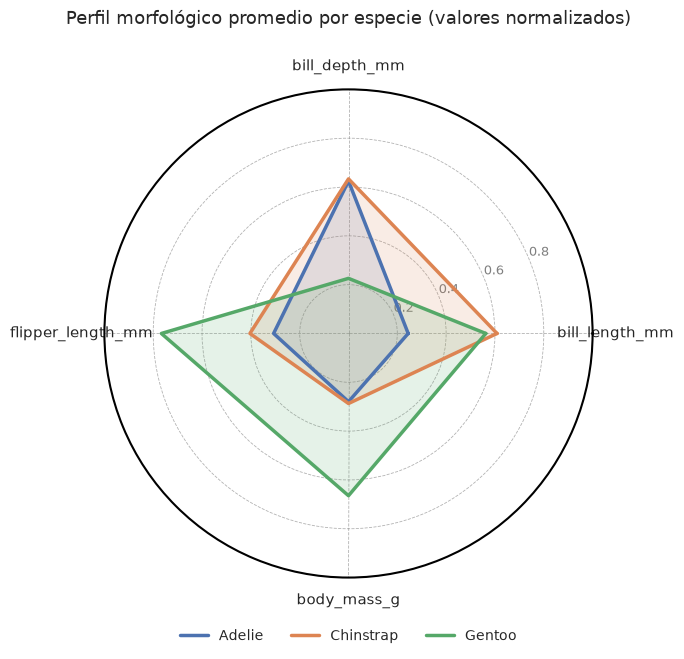

In [70]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
escalado = pd.DataFrame(scaler.fit_transform(pinguinos[num_cols]), columns=num_cols)
escalado["species"] = pinguinos["species"].to_numpy()
promedios_norm = escalado.groupby("species", observed=True)[num_cols].mean()

categorias = list(promedios_norm.columns)
n_cat = len(categorias)
angulos = np.linspace(0, 2 * np.pi, n_cat, endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(7, 7.5), subplot_kw={"projection": "polar"})

for especie in promedios_norm.index:
    valores = promedios_norm.loc[especie].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, label=especie, linewidth=2.5)
    ax.fill(angulos, valores, alpha=0.15)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11)

ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=9, color="gray")

ax.grid(color="gray", linestyle="--", linewidth=0.6, alpha=0.6)

ax.spines["polar"].set_color("black")
ax.spines["polar"].set_linewidth(1.5)

ax.set_title("Perfil morfológico promedio por especie (valores normalizados)", fontsize=13, pad=25)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

Se asemeja mucho a lo analizado anteriormente donde `Adelie` y `Chinstrap` son muy similares en cuanto a su peso corporal y la profundidad del pico, pero diferentes en su largo.

# Ejercicio 4: Muestreo y Reducción Dimensional 
Implemente estrategias de muestreo inteligente y técnicas de reducción dimensional para el manejo eficiente de datos.  
Tareas a realizar: 
- Implemente diferentes estrategias de muestreo: aleatorio simple y estratificado por especie, comparando la representatividad de cada método. Utilice gráficos adecuados para reflejar la composición de los datos. Considere el método `.sample` de `pandas.DataFrame` para muestreo aleatorio, el método `.groupby` y `.sample` para muestreo estratificado balanceado y `train_test_split` de `sklearn.model_selection` con el parámetro `stratify` para muestreo estratificado manteniendo las proporciones originales de las especies. 
- Aplique Análisis de Componentes Principales (PCA) para reducir la dimensionalidad del dataset manteniendo al menos 95% de la varianza explicada. Recordar que se debe normalizar previamente las variables. Se propone el uso de `StandarScaler` de `sklearn.preprocessing` y PCA de `sklearn.decomposition`. Visualice los datos originales (pairplot) y transformados mediante PCA (2 dimensiones), interpretando los componentes principales obtenidos. La reducción a dos componentes 
puede realizarse con PCA(n_components=2). 
- Evalúe la pérdida de información asociada con diferentes niveles de reducción dimensional. Se recomienda representar gráficamente la varianza acumulada retenida con `explained_variance_ratio_`. 
- Aplique una técnica de reducción dimensional no lineal, como t-SNE, y compare la representación obtenida con la proyección mediante PCA en dos dimensiones. Analice visualmente la separación entre especies y discuta las principales diferencias entre ambas representaciones. Considere el uso de TSNE de sklearn.manifold.

Determine cuál es la estrategia más adecuada para el manejo de datos que preserva de mejor manera la información esencial, mejorando la eficiencia computacional y la interpretabilidad visual. 

### 4.1 Estrategias de muestreo: aleatorio simple vs. estratificado


In [71]:
print("Proporciones de especie en el dataset completo:")
print(pinguinos["species"].value_counts(normalize=True))

Proporciones de especie en el dataset completo:
species
Adelie       0.438438
Gentoo       0.357357
Chinstrap    0.204204
Name: proportion, dtype: float64


Se puede ver un claro desbalance entre las clases de especies, por lo que aplicar un muestreo simple no es lo correcto aunque lo haremos a fines de resolver el ejercicio.

In [76]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42 # semilla

# Muestreo aleatorio simple (20%)
muestra_aleatoria = pinguinos.sample(frac=0.2, random_state=RANDOM_STATE)

# Muestreo estratificado simple: mismo n de cada especie (groupby + sample)
# 1. Cuento cuantos pinguinos hay de cada especie
conteo_por_especie = pinguinos["species"].value_counts()

# 2. Me quedo con el número de la especie que tiene MENOS pingüinos
n_min = conteo_por_especie.min()

# 3. De cada especie, tomo esa misma cantidad al azar
# Así las tres especies quedan representadas en igual proporción en la muestra
muestra_estratificada = pinguinos.groupby("species", observed=True).sample(
    n=n_min,
    random_state=RANDOM_STATE
)
# contás cuántos hay de la especie más chica, y le pedís esa misma cantidad a las tres especies,
#  para que ninguna quede sobre-representada en la muestra final.

In [79]:
# Muestreo estratificado manteniendo proporciones originales (train_test_split con stratify)
# train_test_split normalmente se usa para separar train/test,
# pero acá lo usamos solo para "cortar" una muestra del 20% de los datos

muestra_estratificada_proporcional, _ = train_test_split(
    pinguinos,
    train_size=0.2,          # me quedo con el 20% de los datos
    stratify=pinguinos["species"],  # respetando las proporciones de cada especie
    random_state=RANDOM_STATE
)

resumen_muestreo = pd.DataFrame({
    "completo": pinguinos["species"].value_counts(normalize=True),
    "aleatorio_simple": muestra_aleatoria["species"].value_counts(normalize=True),
    "estratificado_balanceado": muestra_estratificada["species"].value_counts(normalize=True),
    "estratificado_proporcional": muestra_estratificada_proporcional["species"].value_counts(normalize=True),
}).round(3)
resumen_muestreo

,completo,aleatorio_simple,estratificado_balanceado,estratificado_proporcional
species,,,,
Adelie,0.438,0.463,0.333,0.439
Chinstrap,0.204,0.194,0.333,0.197
Gentoo,0.357,0.343,0.333,0.364


El muestreo aleatorio simple no controla la composición por especie, por lo que sus proporciones fluctúan por azar respecto a la población; el estratificado proporcional, en cambio, fija esas proporciones de antemano y solo aplica el azar dentro de cada grupo, reproduciendo casi exactamente la distribución original.

Cuanto más grande sea la muestra, más se van a parecer el aleatorio simple y el estratificado.

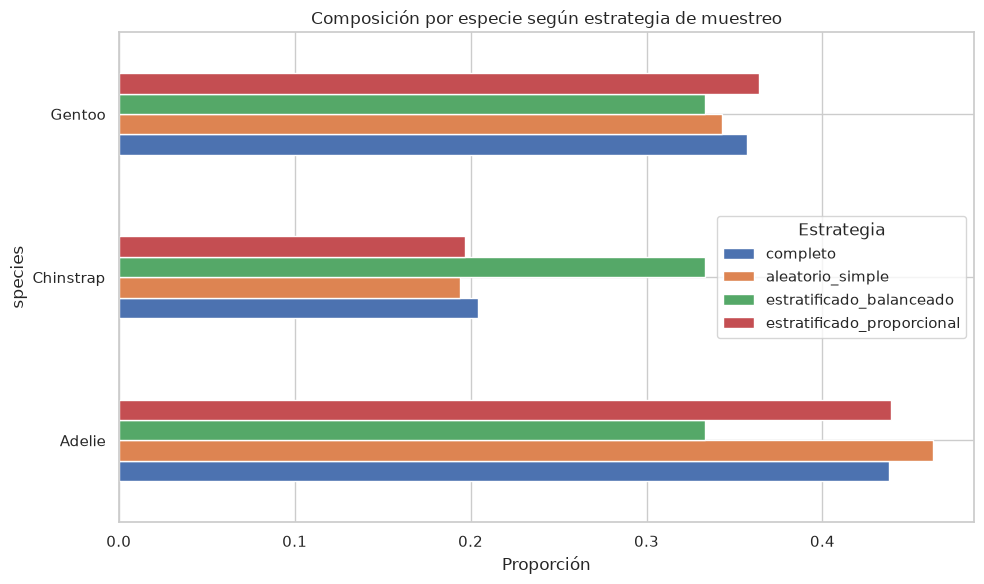

In [107]:
resumen_muestreo.plot(kind="barh", figsize=(10, 6))
plt.title("Composición por especie según estrategia de muestreo")
plt.xlabel("Proporción")
plt.yticks(rotation=0)
plt.legend(title="Estrategia")
plt.tight_layout()
plt.show()

**Lectura:** el muestreo aleatorio simple aproxima razonablemente las proporciones originales, pero
con algo de variación esperable por azar. El muestreo estratificado proporcional (`train_test_split`
con `stratify`) reproduce casi exactamente las proporciones del dataset completo — es la opción
recomendada cuando el objetivo es preservar la representatividad. El muestreo estratificado
balanceado, en cambio, iguala deliberadamente el tamaño de cada especie (útil si se quiere evitar
que una especie minoritaria quede subrepresentada en un análisis o modelo posterior, a costa de no
reflejar la proporción real de la población).

### 4.2 Análisis de Componentes Principales (PCA)

In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Estandarizo los datos (PCA es sensible a la escala)
X_estandarizado = StandardScaler().fit_transform(pinguinos[num_cols])

# 2. Aplico PCA con todos los componentes posibles
pca = PCA(random_state=RANDOM_STATE).fit(X_estandarizado)

# 3. Vemos cuánta varianza explica tiene cada componente, y la acumulada
varianza_por_componente = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_por_componente)

print("Varianza explicada por componente:", varianza_por_componente.round(3))
print("Varianza acumulada:", varianza_acumulada.round(3))

# 4. Cuántos componentes necesito para llegar al 95%? => 3
# n_componentes_95 = None
# for i, valor in enumerate(varianza_acumulada, start=1):
#     if valor >= 0.95:
#         n_componentes_95 = i
#         break
# print(f"Componentes necesarios para retener >= 95% de la varianza: {n_componentes_95}")

Varianza explicada por componente: [0.686 0.195 0.092 0.027]
Varianza acumulada: [0.686 0.881 0.973 1.   ]


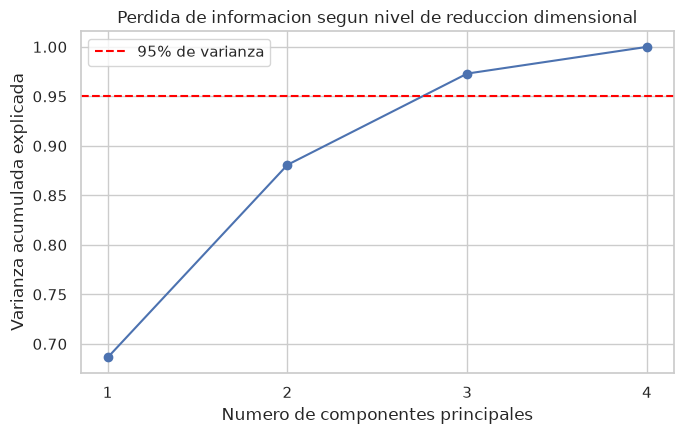

In [100]:
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")

plt.axhline(0.95, color="red", linestyle="--", label="95% de varianza")

plt.xlabel("Numero de componentes principales")
plt.ylabel("Varianza acumulada explicada")

plt.title("Perdida de informacion segun nivel de reduccion dimensional")
plt.xticks(range(1, len(varianza_acumulada) + 1))

plt.legend()
plt.tight_layout()
plt.show()

**Lectura:** el primer componente principal explica solo el 68.6% de la varianza total, y recién con 3 de las 4 componentes se supera el umbral del 95% (línea roja), esto indica que, si bien existe cierta redundancia entre las variables morfológicas (coherente con las correlaciones altas observadas en el dendrograma del Ejercicio 3), la reducción dimensional posible es moderada: no alcanza con 1 o 2 componentes para representar fielmente los datos, y se necesitan prácticamente todas las variables originales para no perder información relevante.

### 4.3 Visualización: datos originales (pairplot) vs. proyección PCA en 2D

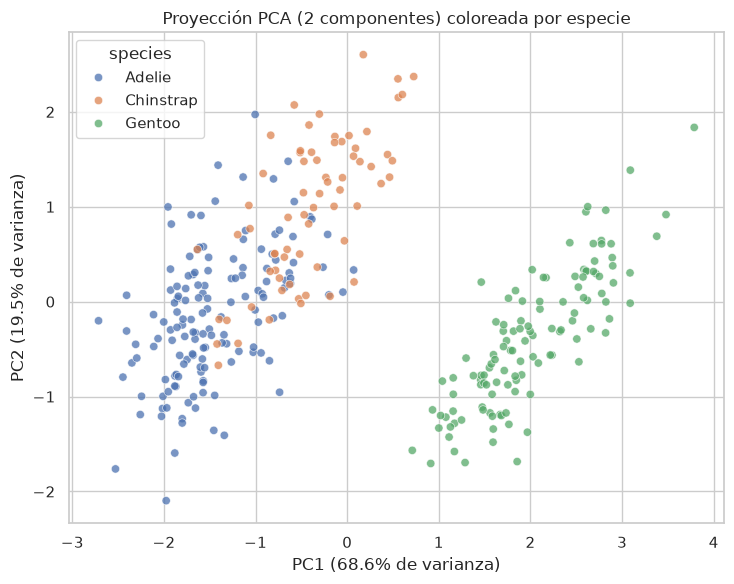

In [101]:
# 1. Reduzco a 2 componentes principales
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
componentes_2d = pca_2d.fit_transform(X_estandarizado)

# 2. Armo un DataFrame con los resultados, para poder graficar fácil con seaborn
pca_df = pd.DataFrame(componentes_2d, columns=["PC1", "PC2"])
pca_df["species"] = pinguinos["species"].to_numpy()

# 3. Calculo qué % de varianza explica cada eje, para ponerlo en las etiquetas
var_pc1, var_pc2 = pca_2d.explained_variance_ratio_ * 100

# 4. Grafico
plt.figure(figsize=(7.5, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="species", alpha=0.75)
plt.xlabel(f"PC1 ({var_pc1:.1f}% de varianza)")
plt.ylabel(f"PC2 ({var_pc2:.1f}% de varianza)")
plt.title("Proyección PCA (2 componentes) coloreada por especie")
plt.tight_layout()
plt.show()

In [103]:
componentes = pd.DataFrame(pca_2d.components_.T, index=num_cols, columns=["PC1", "PC2"]).round(3)
componentes

,PC1,PC2
bill_length_mm,0.454,0.600
bill_depth_mm,-0.399,0.796
flipper_length_mm,0.577,0.006
body_mass_g,0.550,0.076


**Interpretación de las componentes:** PC1 concentra el 68.6% de la varianza y pondera con el mismo signo a `flipper_length_mm` (0.58), `body_mass_g` (0.55) y `bill_length_mm` (0.45), mientras que `bill_depth_mm` pesa en sentido opuesto (-0.40), puede leerse como un eje general de "tamaño corporal", donde valores altos de PC1 corresponden a pingüinos más grandes y con pico más alargado pero menos profundo. Este único eje ya separa claramente a Gentoo (PC1 alto) del resto. PC2, en cambio, está dominado casi exclusivamente por `bill_depth_mm` (0.80) y `bill_length_mm` (0.60), con pesos prácticamente nulos de `flipper_length_mm` y `body_mass_g` — funciona como un eje de "forma del pico" independiente del tamaño corporal, y es lo que permite distinguir a Adelie de Chinstrap, dos especies
de tamaño similar pero con picos morfológicamente distintos. En conjunto, dos componentes alcanzan para visualizar una separación de especies.

PC1 Explica mejor tamaño corporal del pinguino, mientras que PC2, funciona como un eje de "forma de pico".

### 4.4 Reducción no lineal: t-SNE vs. PCA

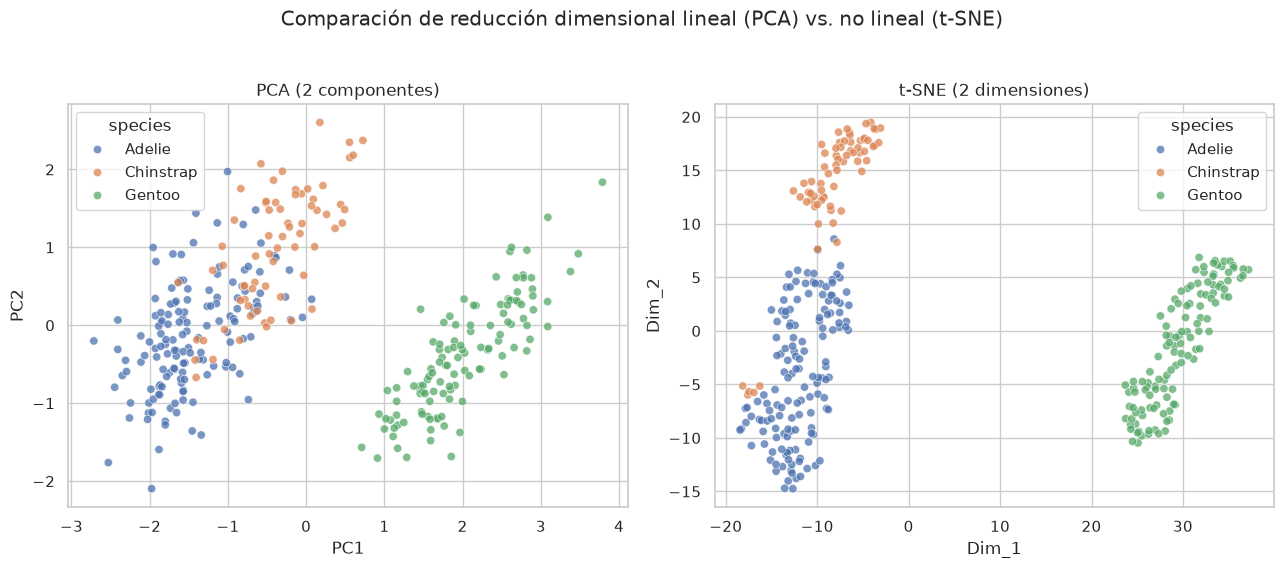

In [ ]:
from sklearn.manifold import TSNE

# 1. Reducimos a 2 dimensiones con t-SNE (método no lineal, distinto de PCA)
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init="pca")
componentes_tsne = tsne.fit_transform(X_estandarizado)

# 2. Armamos un DataFrame con los resultados para graficar fácil
tsne_df = pd.DataFrame(componentes_tsne, columns=["Dim_1", "Dim_2"])
tsne_df["species"] = pinguinos["species"].to_numpy()

# 3. Graficamos PCA y t-SNE lado a lado para comparar
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="species", alpha=0.75, ax=axes[0])
axes[0].set_title("PCA (2 componentes)")

sns.scatterplot(data=tsne_df, x="Dim_1", y="Dim_2", hue="species", alpha=0.75, ax=axes[1])
axes[1].set_title("t-SNE (2 dimensiones)")

fig.suptitle("Comparación de reducción dimensional lineal (PCA) vs. no lineal (t-SNE)", y=1.03)
fig.tight_layout()
plt.show()

**Lectura:** ambas técnicas separan bien a Gentoo del resto, pero t-SNE logra una mejor separación 
entre Adelie y Chinstrap (dos clusters bien delimitados y casi sin superposición), mientras que en PCA
esas dos especies todavía se solapan. Esto es esperable:

PCA está restringido a combinaciones lineales de las variables originales, mientras que t-SNE modela
similitudes locales de forma no lineal, lo que le permite separar mejor estructuras que no son
linealmente separables en el espacio original. 

Pero en t-SNE las distancias entre clusters y la escala de los ejes no tienen una interpretación directa (a diferencia de PCA, donde cada
eje es una combinación lineal interpretable de las variables originales, con varianza explicada
conocida) por lo que no lo usaremos para interpretar qué variables
explican la separación.